## 1. Importing Libraries

In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import joblib

## 2. Load Dataset

In [14]:
df = pd.read_csv("F:\Projects\Customer Churn Prediction Model\Customer_Churn.csv")

print(df.shape)
print(df.head())

# Check missing values
print(df.isnull().sum())

(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

## 3. Data Cleaning

In [15]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [16]:
df.columns = df.columns.str.strip()

print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [17]:
df.drop("customerID", axis=1, inplace=True)

In [19]:
# Convert TotalCharges to numeric

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Fill missing values

df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

print(df.isnull().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


## 4. Exploratory Data Analysis


### Churn Distribution

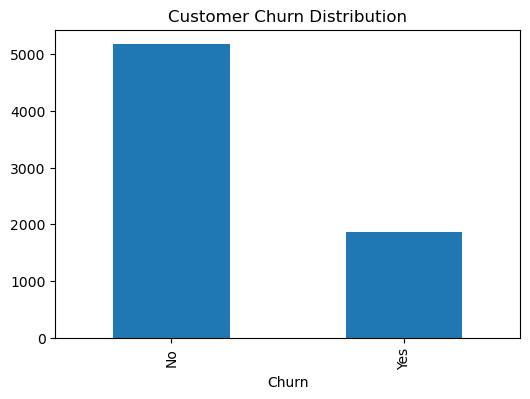

In [20]:
plt.figure(figsize=(6,4))

df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")

plt.show()

### Contract Analysis

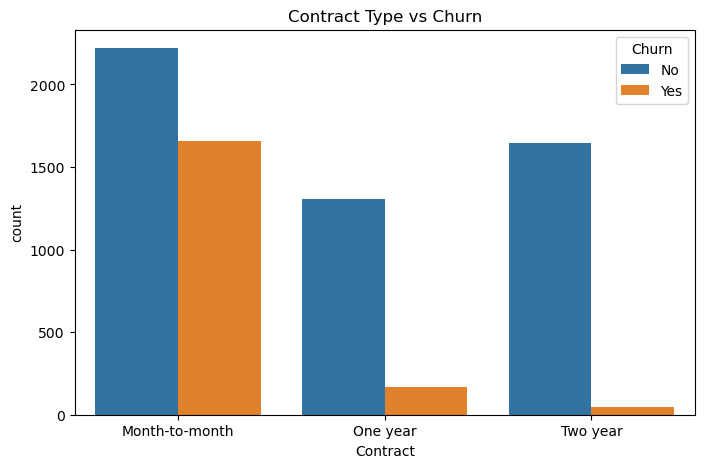

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.title("Contract Type vs Churn")

plt.show()

### Monthly Charges Distribution

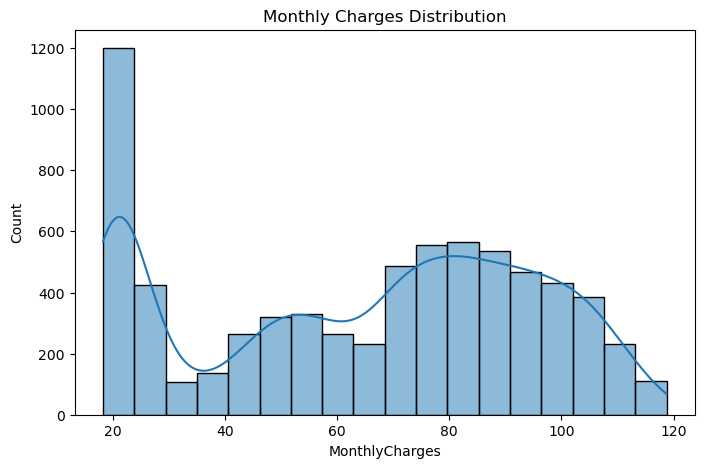

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["MonthlyCharges"],
    kde=True
)

plt.title("Monthly Charges Distribution")

plt.show()

## 5. Feature Encoding

In [23]:
encoder = LabelEncoder()

for col in df.columns:

    if df[col].dtype == "object":

        df[col] = encoder.fit_transform(
            df[col]
        )

## 6. Correlation Heatmap

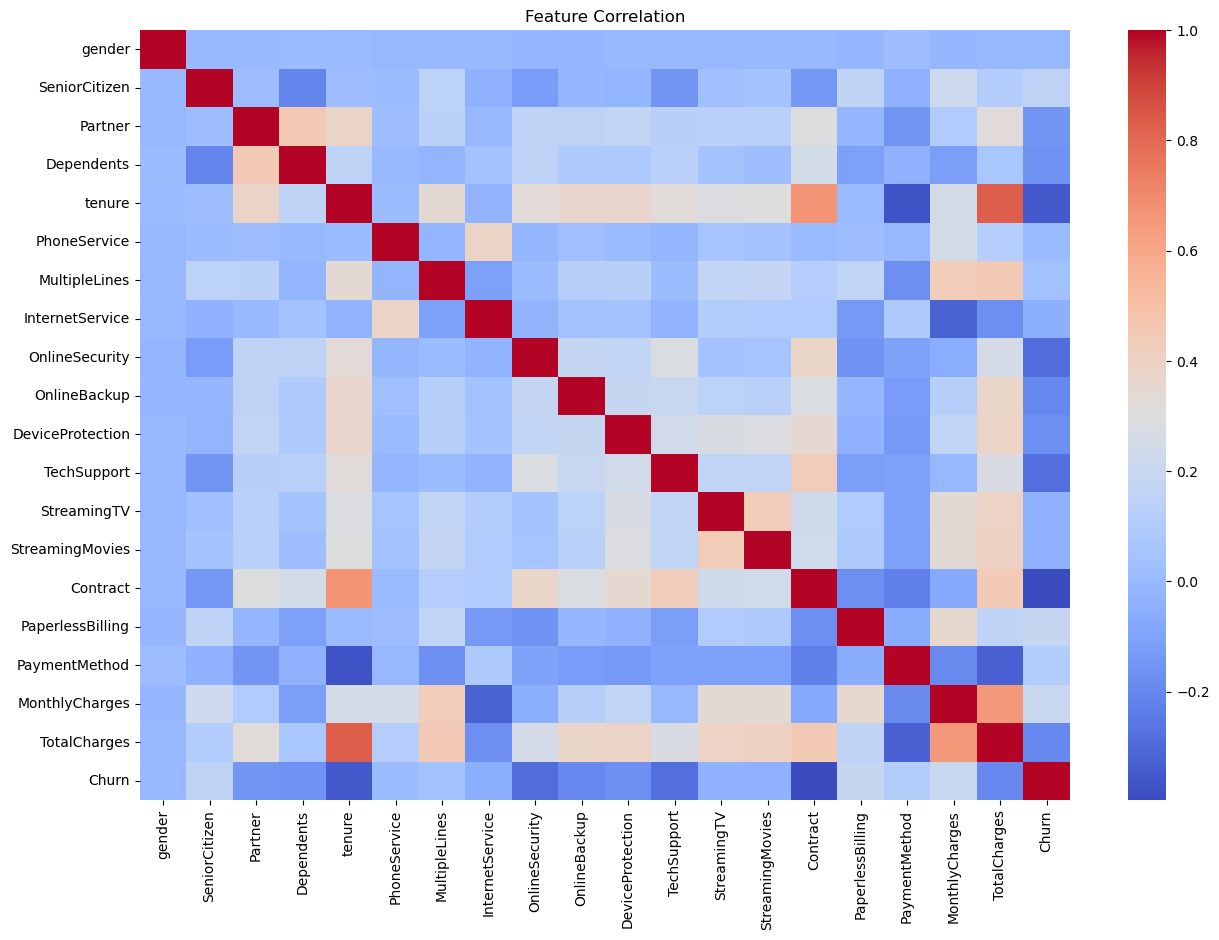

In [24]:
plt.figure(figsize=(15,10))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.title("Feature Correlation")

plt.show()

## 7. Train-Test Split

In [25]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## 8. Logistic Regression

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=2000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print(
    "Logistic Regression Accuracy:",
    round(accuracy_score(y_test, lr_pred) * 100, 2),
    "%"
)

Logistic Regression Accuracy: 81.55 %


In [28]:
lr = LogisticRegression(
    max_iter=5000
)

## 9. Random Forest

In [30]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(
    X_test
)

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print(
    "Random Forest Accuracy:",
    round(rf_accuracy*100,2),
    "%"
)

Random Forest Accuracy: 79.77 %


## 10. Confusion Matrix

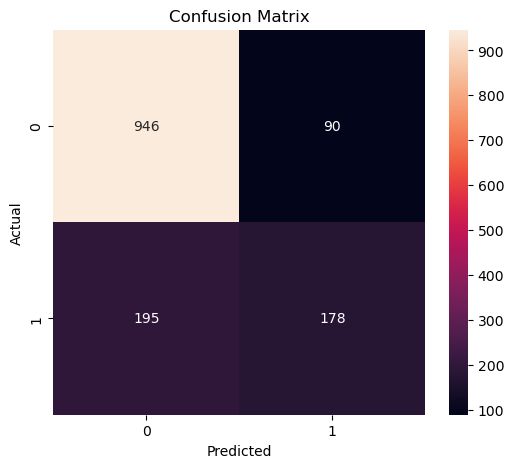

In [32]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## 11. Classification Report

In [33]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.48      0.56       373

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.71      1409
weighted avg       0.79      0.80      0.79      1409



## 12. Feature Importance

In [34]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
    rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(
    importance.head(10)
)

            Feature  Importance
18     TotalCharges    0.189999
17   MonthlyCharges    0.177173
4            tenure    0.159561
14         Contract    0.077461
16    PaymentMethod    0.050327
8    OnlineSecurity    0.047975
11      TechSupport    0.040406
0            gender    0.027588
9      OnlineBackup    0.026792
7   InternetService    0.026275


## Visualization

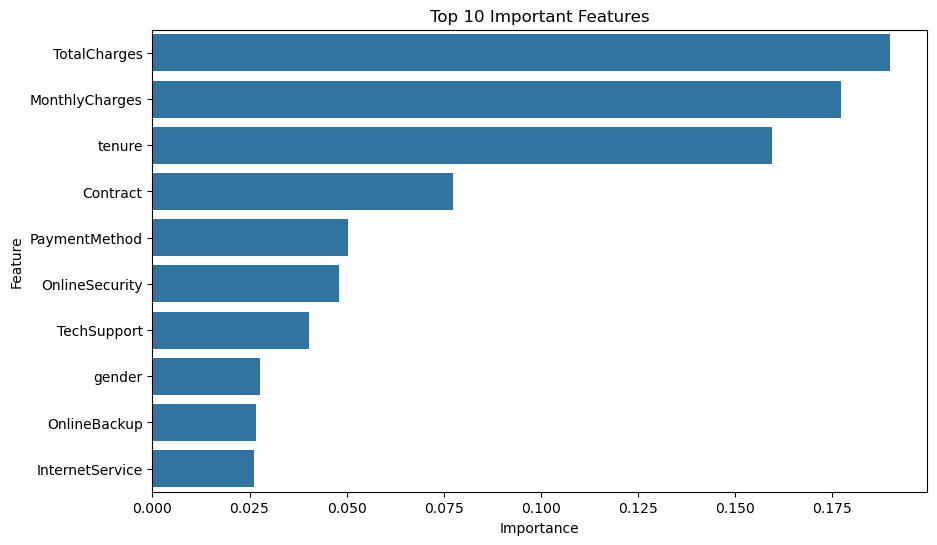

In [35]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10)
)

plt.title(
    "Top 10 Important Features"
)

plt.show()

## 13. Model Comparison

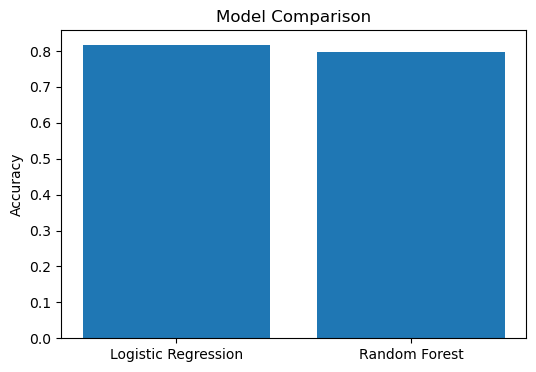

In [36]:
models = [
    "Logistic Regression",
    "Random Forest"
]

scores = [
    lr_accuracy,
    rf_accuracy
]

plt.figure(figsize=(6,4))

plt.bar(
    models,
    scores
)

plt.ylabel("Accuracy")

plt.title(
    "Model Comparison"
)

plt.show()

## 14. Save Best Model

In [37]:
joblib.dump(
    rf,
    "random_forest.pkl"
)

print(
    "Model Saved Successfully"
)

Model Saved Successfully
